# Value at Risk Analysis

This case studies the value at risk of a portfolio consisting of Google (45%), Facebook (32%), Nvidia (10%), Coursera (13%). The stock prices are imported for yfinance api. The portfolio assumes rebalancing daily to maintain the percentages above despite price flactuations. 

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt 
from scipy.stats import skew, variation
from Value_at_Risk import get_multivar_norm, get_portfolio_data, get_portfolio_returns, get_stock_returns, get_cov_matrix

Set you derised tickers and dates then get the data. Lookback: 10 years.

In [2]:
tickers = ['GOOG', 'META', 'NVDA', 'COUR']
weights = [0.45, 0.32, 0.1, 0.13]
tot_val = 5 * 10**5

start_date = '2015-03-19'
end_date = '2025-03-19'

In [3]:
df = get_portfolio_data(tickers, start_date, end_date)

[*********************100%***********************]  4 of 4 completed


Task A: Calculate the historical VaR at 1% for 1 month holdings. Here we assume 21 trading days in month.

In [4]:
returns = get_stock_returns(df, 21)
close_data = df.loc[:, pd.IndexSlice[:, 'Close']]
stock_returns = get_stock_returns(close_data, 21) #one month returns

PnL = get_portfolio_returns(stock_returns, tickers, weights)
historic_var = np.percentile(PnL, 1)

print(f'The simple historical VaR is {abs(historic_var*tot_val):.2f} USD or ({abs(np.mean(historic_var)*100):.1f}%)')

The simple historical VaR is 83193.12 USD or (16.6%)


Calculate the expected shortfall (ES).

In [5]:
ES = []
for r in PnL:
    if r<=historic_var:
        ES.append(r)
print(f'The historical expected shortfall is {abs(np.mean(ES)*tot_val):.2f} USD or ({abs(np.mean(ES)*100):.1f}%)')

The historical expected shortfall is 104572.26 USD or (20.9%)


Task B: Implement a simulated Monte Carlo and calculate the 1% VaR for 1m USD holdings. The assumption here is that the percentile returns (given by the function 'get_stock_returns') of each of the stocks are normally distributed. The daily returns can then be used to get a mean and a covariance matrix to create a multi-variate normal, from which samples are drawn over a month (which is assumed to be 21 trading days). 

In [6]:
daily_returns = get_stock_returns(df, 1)
daily_returns = daily_returns.loc[:, pd.IndexSlice[:, 'Close']] 
daily_returns_mean = daily_returns.mean(axis=0)
daily_cov = get_cov_matrix(daily_returns)

In [7]:
dist = []
for i in range(10000):
    sim = pd.DataFrame(get_multivar_norm(daily_returns_mean, daily_cov, 21), columns = tickers)
    port_returns = np.array(get_portfolio_returns(sim, tickers, weights), dtype=float)
    # Compound 21 daily portfolio returns: (1+r1)*(1+r2)*...*(1+r21) - 1
    compounded_return = np.prod(1 + port_returns) - 1
    dist.append(compounded_return)

dist = np.array(dist, dtype=float)

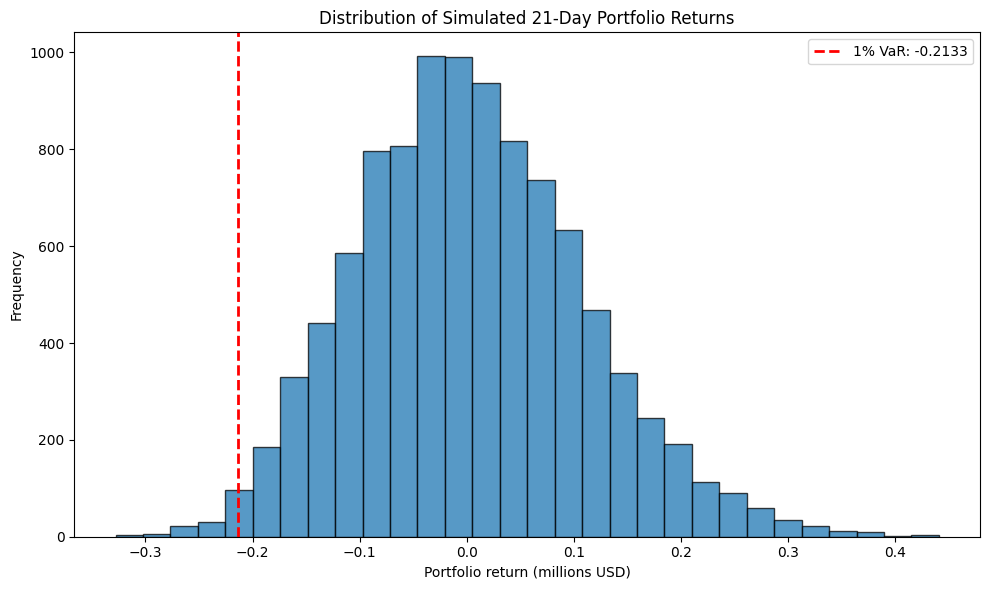

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(dist, bins=30, edgecolor='black', alpha=0.75)
plt.title('Distribution of Simulated 21-Day Portfolio Returns')
plt.xlabel('Portfolio return (millions USD)')
plt.ylabel('Frequency')

# Show risk marker (1% quantile)
var_1 = np.percentile(dist, 1)
plt.axvline(var_1, color='red', linestyle='--', linewidth=2, label=f'1% VaR: {var_1:.4f}')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
print(f'The final distribution has a skewness of {skew(dist):.2f}, a mean of {np.mean(dist):.2f} and a variance of {variation(dist):.2f}')

The final distribution has a skewness of 0.34, a mean of 0.00 and a variance of 28.37


The 1% VaR at 22% is slightly higher than the historical VaR of 17%. This can be attributed to the later incorporated Coursera (trading for 5 out of 10 years) that has had a downward trend since listing (85-90% fall since listing). It is therefore expected that the model shows a higher VaR than the 10 year historical average. The slight skewness indicates that more points are to the right of the mean (i.e. positive returns for a mean of 0.0).

To visualise the distribution of the model, selected Monte Carlo paths can be plotted.

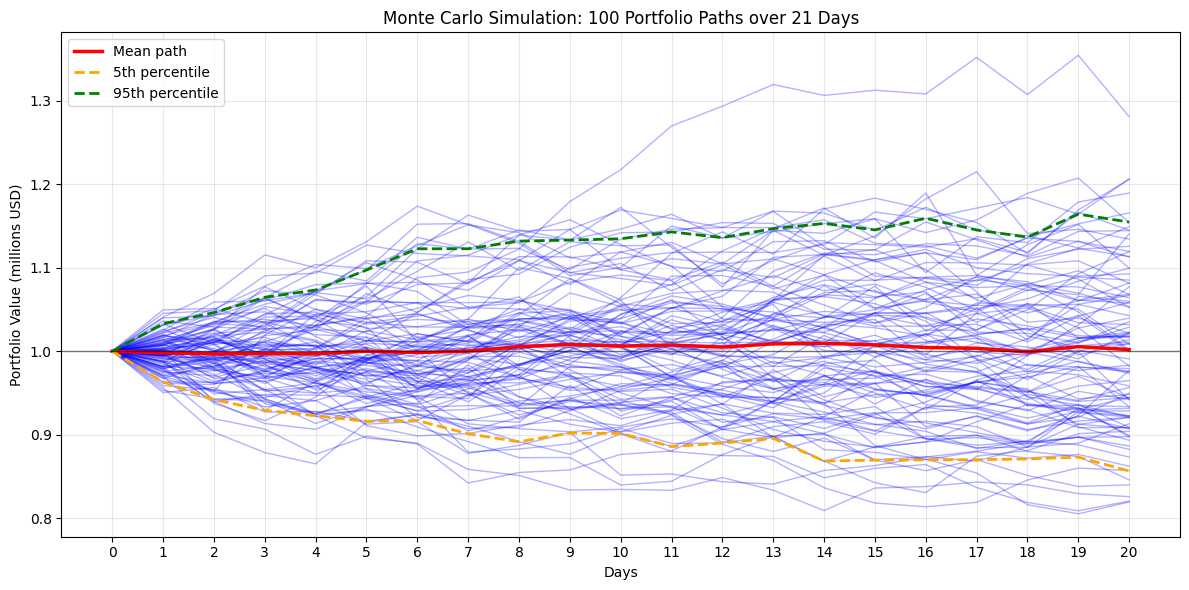

In [10]:
num_paths = 100
num_days = 21
initial_value = 1.0  # normalized to 1

paths = np.zeros((num_paths, num_days))
paths[:, 0] = initial_value

for path_idx in range(num_paths):
    sim = pd.DataFrame(
        get_multivar_norm(daily_returns_mean, daily_cov, num_days - 1),  # ← Generate 20 returns
        columns=tickers
    )
    port_daily_returns = np.array(get_portfolio_returns(sim, tickers, weights), dtype=float)
    
    # Compound daily returns to get cumulative portfolio value
    cumulative = np.cumprod(1 + port_daily_returns)  # Now 20 values
    paths[path_idx, 1:] = cumulative  # Fits into slots 1-20

# Plot paths
plt.figure(figsize=(12, 6))
plt.plot(paths.T, alpha=0.3, color='blue', linewidth=1)

# Add mean path
mean_path = paths.mean(axis=0)
plt.plot(mean_path, color='red', linewidth=2.5, label='Mean path')

# Add percentiles
percentile_5 = np.percentile(paths, 5, axis=0)
percentile_95 = np.percentile(paths, 95, axis=0)
plt.plot(percentile_5, color='orange', linestyle='--', linewidth=2, label='5th percentile')
plt.plot(percentile_95, color='green', linestyle='--', linewidth=2, label='95th percentile')

plt.axhline(y=1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.xlabel('Days')
plt.ylabel('Portfolio Value (millions USD)')
plt.title(f'Monte Carlo Simulation: {num_paths} Portfolio Paths over {num_days} Days')
plt.xticks(range(0,21))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()